In [45]:
# ── CELL 1: Imports & Config ─────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.transform import from_bounds
from rasterio.features import rasterize
from rasterstats import zonal_stats
from shapely.geometry import mapping, box
from scipy.ndimage import zoom, uniform_filter, distance_transform_edt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
import yaml
warnings.filterwarnings('ignore')

with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

PROCESSED_DIR = '../data/processed/'
OUTPUT_DIR    = '../outputs/static/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MIN_LON = config['study_area']['bbox']['min_lon']
MAX_LON = config['study_area']['bbox']['max_lon']
MIN_LAT = config['study_area']['bbox']['min_lat']
MAX_LAT = config['study_area']['bbox']['max_lat']

GRID_W, GRID_H   = 1000, 700
TARGET_SHAPE     = (GRID_H, GRID_W)
MASTER_TRANSFORM = from_bounds(MIN_LON, MIN_LAT, MAX_LON, MAX_LAT, GRID_W, GRID_H)

print("✅ Config loaded")

✅ Config loaded


In [48]:
# ── CELL 2: Load Data ────────────────────────────────────────
print("Loading all data layers...")

unions = gpd.read_file(f'{PROCESSED_DIR}netrokona_boundaries.geojson').to_crs('EPSG:4326')
if len(unions) < 20:
    print(f"⚠  Only {len(unions)} features — fetching GADM Level 4...")
    gadm_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_BGD_4.json"
    all_bd   = gpd.read_file(gadm_url)
    unions   = all_bd[
        all_bd['NAME_2'].str.contains('Netrakona|Netrokona', case=False, na=False)
    ].copy().to_crs('EPSG:4326')
    unions['union_name']   = unions['NAME_4']
    unions['upazila_name'] = unions['NAME_3']
    unions['union_id']     = range(len(unions))
    unions.to_file(f'{PROCESSED_DIR}netrokona_boundaries.geojson', driver='GeoJSON')

for col, fallbacks, prefix in [
    ('union_name',   ['NAME_4', 'shapeName', 'name'], 'Union'),
    ('upazila_name', ['NAME_3', 'shapeGroup'],         'Upazila'),
]:
    if col not in unions.columns:
        for fb in fallbacks:
            if fb in unions.columns:
                unions[col] = unions[fb]; break
        else:
            unions[col] = [f'{prefix}_{i}' for i in range(len(unions))]
if 'union_id' not in unions.columns:
    unions['union_id'] = range(len(unions))

health     = gpd.read_file(f'{PROCESSED_DIR}netrokona_health_facilities.geojson').to_crs('EPSG:4326')
shelters   = gpd.read_file(f'{PROCESSED_DIR}netrokona_shelters.geojson').to_crs('EPSG:4326')
roads      = gpd.read_file(f'{PROCESSED_DIR}netrokona_roads.geojson').to_crs('EPSG:4326')
flood_2024 = gpd.read_file(f'{PROCESSED_DIR}flood_exposure_results.geojson').to_crs('EPSG:4326')
rainfall   = pd.read_csv(f'{PROCESSED_DIR}netrokona_rainfall.csv')

rivers_path = f'{PROCESSED_DIR}netrokona_rivers.geojson'
rivers = gpd.read_file(rivers_path).to_crs('EPSG:4326') \
         if os.path.exists(rivers_path) \
         else gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')

print(f"✅ Unions: {len(unions)} | Health: {len(health)} | "
      f"Shelters: {len(shelters)} | Roads: {len(roads)} | Rivers: {len(rivers)}")



Loading all data layers...
✅ Unions: 92 | Health: 8 | Shelters: 15 | Roads: 23301 | Rivers: 346


In [49]:
# ── CELL 3: Helper Functions ─────────────────────────────────
def load_raster_to_grid(path, target_shape=TARGET_SHAPE):
    bbox_geom = [mapping(box(MIN_LON, MIN_LAT, MAX_LON, MAX_LAT))]
    with rasterio.open(path) as src:
        try:
            out_img, _ = mask(src, bbox_geom, crop=True, nodata=-9999)
        except Exception:
            out_img = src.read()
        data = out_img[0].astype(float)
        nd   = src.nodata if src.nodata is not None else -9999
        data[data == nd]  = np.nan
        data[data < -999] = np.nan
    if data.shape != target_shape:
        zy = target_shape[0] / data.shape[0]
        zx = target_shape[1] / data.shape[1]
        data = zoom(data, (zy, zx), order=1)
    return data


def normalize(array, inverse=False):
    """Min-max → [0,1]. inverse=True → high raw = low vulnerability (e.g. elevation)."""
    arr   = np.array(array, dtype=float)
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0 or valid.max() == valid.min():
        return np.zeros_like(arr)
    mn, mx = valid.min(), valid.max()
    norm   = (arr - mn) / (mx - mn)
    return (1 - norm) if inverse else norm


def point_distance_raster(points_gdf, target_shape=TARGET_SHAPE):
    h, w = target_shape
    xx, yy = np.meshgrid(np.linspace(MIN_LON, MAX_LON, w),
                         np.linspace(MIN_LAT, MAX_LAT, h))
    if len(points_gdf) == 0:
        return np.ones(target_shape)
    pts_x = np.array([p.x for p in points_gdf.geometry])
    pts_y = np.array([p.y for p in points_gdf.geometry])
    min_dist = np.full(target_shape, np.inf)
    for px, py in zip(pts_x, pts_y):
        min_dist = np.minimum(min_dist, np.sqrt((xx-px)**2 + (yy-py)**2))
    return min_dist


def line_distance_raster(lines_gdf, target_shape=TARGET_SHAPE):
    if len(lines_gdf) == 0:
        return np.ones(target_shape)
    lr = rasterize(
        [(g, 1) for g in lines_gdf.geometry if g is not None],
        out_shape=target_shape, transform=MASTER_TRANSFORM, fill=0, dtype='uint8'
    )
    dist = distance_transform_edt(1 - lr)
    return dist * (MAX_LON - MIN_LON) / target_shape[1]


def rasterize_vector(gdf, target_shape=TARGET_SHAPE):
    if len(gdf) == 0:
        return np.zeros(target_shape, dtype=float)
    return rasterize(
        [(g, 1) for g in gdf.geometry if g is not None],
        out_shape=target_shape, transform=MASTER_TRANSFORM, fill=0, dtype='float32'
    ).astype(float)


def compute_slope(dem_array, pixel_size_m=100.0):
    dy, dx    = np.gradient(np.nan_to_num(dem_array))
    slope_rad = np.arctan(np.sqrt((dx/pixel_size_m)**2 + (dy/pixel_size_m)**2))
    return np.degrees(slope_rad)


def zonal_mean(raster_array, unions_gdf, transform=MASTER_TRANSFORM):
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
        tmp_path = tmp.name
    with rasterio.open(
        tmp_path, 'w', driver='GTiff',
        height=raster_array.shape[0], width=raster_array.shape[1],
        count=1, dtype='float32', crs='EPSG:4326', transform=transform
    ) as dst:
        dst.write(raster_array.astype('float32'), 1)
    stats = zonal_stats(unions_gdf, tmp_path, stats=['mean'], nodata=np.nan)
    os.unlink(tmp_path)
    return np.array([s['mean'] if s['mean'] is not None else 0 for s in stats])


print("✅ Helper functions ready")

✅ Helper functions ready


In [50]:
# ── CELL 4: Build INDEPENDENT Variable Layers ────────────────
# FIX: Each variable must measure something DISTINCT.
# Old code had vuln_age = education = road_access (all = road distance).
# That tripled road distance's weight and crushed variation.
#
# New set — 7 truly independent variables:
#   1. elevation        — physical hazard (low haors = flood-prone)
#   2. slope            — terrain stability (flat = water pools)
#   3. flood_history    — empirical past inundation
#   4. dist_health      — social access (distance to hospital)
#   5. dist_shelter     — emergency access (distance to shelter)
#   6. dist_road        — isolation (distance to nearest road)
#   7. dist_river       — proximity hazard (close river = more risk)
#
# Convention: 1.0 = most vulnerable, 0.0 = safest

print("Building 7 independent vulnerability layers...")
V = {}

dem_raw = np.nan_to_num(
    load_raster_to_grid(f'{PROCESSED_DIR}netrokona_dem_30m.tif'), nan=0.0
)
dem_raw[dem_raw > 100] = np.nan

# 1. Elevation — low = flood-prone = 1 (INVERT: high elevation is safe)
V['elevation']    = normalize(dem_raw, inverse=True)

# 2. Slope — flat = water pools = 1 (INVERT: steep drains faster = safer)
V['slope']        = normalize(compute_slope(dem_raw), inverse=True)

# 3. Flood history — was it flooded in 2024? 1 = yes = dangerous
V['flood_history']= normalize(rasterize_vector(flood_2024), inverse=False)

# 4. Distance to health — far = 1 = vulnerable
V['dist_health']  = normalize(point_distance_raster(health), inverse=False)

# 5. Distance to shelter — far = 1 = vulnerable
V['dist_shelter'] = normalize(point_distance_raster(shelters), inverse=False)

# 6. Distance to road — far = isolated = 1 = vulnerable
V['dist_road']    = normalize(line_distance_raster(roads), inverse=False)

# 7. River proximity — close = 1 = dangerous (INVERT: far from river = safe)
if len(rivers) > 0:
    V['dist_river'] = normalize(line_distance_raster(rivers), inverse=True)
else:
    # Fallback: use low elevation as proxy for river corridor
    V['dist_river'] = V['elevation'].copy()

print(f"\n✅ {len(V)} independent layers built")
print(f"\n{'Variable':<20} {'Mean':>6}  {'Std':>6}  {'Min':>6}  {'Max':>6}")
print("-" * 50)
for k, v in V.items():
    print(f"{k:<20} {np.nanmean(v):>6.3f}  {np.nanstd(v):>6.3f}  "
          f"{np.nanmin(v):>6.3f}  {np.nanmax(v):>6.3f}")


# ── CELL 5: Check correlation between variables ───────────────
# If two variables correlate > 0.95, one should be dropped.
print("\n📊 Correlation check (flag if > 0.85):")
names = list(V.keys())
flat_mask = ~np.isnan(V['elevation'])
X_check = np.array([V[k][flat_mask] for k in names]).T

corr = np.corrcoef(X_check.T)
flagged = False
for i in range(len(names)):
    for j in range(i+1, len(names)):
        if abs(corr[i,j]) > 0.85:
            print(f"  ⚠  {names[i]} ↔ {names[j]} : r={corr[i,j]:.3f}")
            flagged = True
if not flagged:
    print("  ✅ All variables sufficiently independent")


Building 7 independent vulnerability layers...

✅ 7 independent layers built

Variable               Mean     Std     Min     Max
--------------------------------------------------
elevation             0.739   0.092   0.000   1.000
slope                 0.935   0.046   0.000   1.000
flood_history         0.251   0.434   0.000   1.000
dist_health           0.346   0.207   0.000   1.000
dist_shelter          0.331   0.214   0.000   1.000
dist_road             0.247   0.228   0.000   1.000
dist_river            0.794   0.247   0.000   1.000

📊 Correlation check (flag if > 0.85):
  ⚠  dist_health ↔ dist_shelter : r=0.988


In [51]:
# ── CELL 6: EWM + TOPSIS ────────────────────────────────────
print("\nRunning EWM + TOPSIS...")

X = np.array([V[k][flat_mask] for k in names]).T  # (pixels, vars)

# --- ENTROPY WEIGHTING ---
X_eps   = X + 1e-9
P       = X_eps / X_eps.sum(axis=0)
k_ent   = 1.0 / np.log(X.shape[0])
entropy = -k_ent * np.nansum(P * np.log(P + 1e-12), axis=0)

# Clip entropy to [0,1] — can exceed 1 due to floating point
entropy = np.clip(entropy, 0, 1)

dispersion  = 1 - entropy
ewm_weights = dispersion / dispersion.sum()

print("\n--- EWM WEIGHTS ---")
for n, w in sorted(zip(names, ewm_weights), key=lambda x: -x[1]):
    bar = "█" * int(w * 100)
    print(f"  {n:<20} {w:.4f}  {bar}")
print(f"  Sum: {ewm_weights.sum():.4f}")

# --- TOPSIS ---
V_weighted  = X * ewm_weights
ideal_best  = np.max(V_weighted, axis=0)   # most vulnerable reference
ideal_worst = np.min(V_weighted, axis=0)   # safest reference

dist_best   = np.sqrt(np.sum((V_weighted - ideal_best )**2, axis=1))
dist_worst  = np.sqrt(np.sum((V_weighted - ideal_worst)**2, axis=1))

topsis_score = dist_worst / (dist_best + dist_worst + 1e-12)

FVI_MAP            = np.full(TARGET_SHAPE, np.nan)
FVI_MAP[flat_mask] = topsis_score

print(f"\n✅ TOPSIS raw range: [{np.nanmin(FVI_MAP):.3f}, {np.nanmax(FVI_MAP):.3f}]")



Running EWM + TOPSIS...

--- EWM WEIGHTS ---
  flood_history        0.5934  ███████████████████████████████████████████████████████████
  dist_road            0.2020  ████████████████████
  dist_shelter         0.0949  █████████
  dist_health          0.0800  ████████
  dist_river           0.0256  ██
  elevation            0.0034  
  slope                0.0006  
  Sum: 1.0000

✅ TOPSIS raw range: [0.037, 0.774]


In [52]:
# ── CELL 7: Union Scores + Percentile Classification ─────────
# FIX: Use PERCENTILE-BASED classification instead of fixed thresholds.
# Fixed thresholds (0.2, 0.4, 0.6, 0.8) always produce skewed maps
# when scores cluster. Percentiles guarantee meaningful class spread.

print("\nComputing union vulnerability scores...")
unions['fvi_raw'] = zonal_mean(FVI_MAP, unions)

# Normalize to [0,1]
mn = unions['fvi_raw'].min()
mx = unions['fvi_raw'].max()
unions['FVI_Index'] = (unions['fvi_raw'] - mn) / (mx - mn + 1e-9)

# Percentile-based classification (roughly equal-count classes)
p20 = np.percentile(unions['FVI_Index'], 20)
p40 = np.percentile(unions['FVI_Index'], 40)
p60 = np.percentile(unions['FVI_Index'], 60)
p80 = np.percentile(unions['FVI_Index'], 80)

print(f"\n  Percentile thresholds: "
      f"P20={p20:.3f} | P40={p40:.3f} | P60={p60:.3f} | P80={p80:.3f}")

def classify(score):
    if   score >= p80: return 'Very High'
    elif score >= p60: return 'High'
    elif score >= p40: return 'Moderate'
    elif score >= p20: return 'Low'
    else:              return 'Very Low'

unions['vuln_class'] = unions['FVI_Index'].apply(classify)

# Dimension scores for tooltip
for dim, raster in [
    ('vuln_physical',  normalize(0.5*V['elevation'] + 0.5*V['slope'])),
    ('vuln_hazard',    normalize(0.5*V['flood_history'] + 0.5*V['dist_river'])),
    ('vuln_social',    normalize(0.4*V['dist_health'] + 0.4*V['dist_shelter'] + 0.2*V['dist_road'])),
]:
    unions[dim] = zonal_mean(raster, unions)

# Save CSV
csv_path = f'{OUTPUT_DIR}netrokona_union_vulnerability.csv'
unions[['union_id', 'union_name', 'upazila_name',
        'FVI_Index', 'vuln_class',
        'vuln_physical', 'vuln_hazard', 'vuln_social']]\
    .sort_values('FVI_Index', ascending=False)\
    .to_csv(csv_path, index=False)
print(f"\n✅ CSV saved → {csv_path}")

print("\nVulnerability distribution:")
for cls in ['Very High', 'High', 'Moderate', 'Low', 'Very Low']:
    n   = (unions['vuln_class'] == cls).sum()
    pct = n / len(unions) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls:<12} {n:>3} unions ({pct:5.1f}%) {bar}")

print("\nTop 10 most vulnerable unions:")
print(unions.nlargest(10, 'FVI_Index')[
    ['union_name', 'upazila_name', 'FVI_Index', 'vuln_class']
].to_string(index=False))


Computing union vulnerability scores...

  Percentile thresholds: P20=0.947 | P40=0.954 | P60=0.961 | P80=0.970

✅ CSV saved → ../outputs/static/netrokona_union_vulnerability.csv

Vulnerability distribution:
  Very High     19 unions ( 20.7%) ██████████
  High          18 unions ( 19.6%) █████████
  Moderate      18 unions ( 19.6%) █████████
  Low           18 unions ( 19.6%) █████████
  Very Low      19 unions ( 20.7%) ██████████

Top 10 most vulnerable unions:
          union_name upazila_name  FVI_Index vuln_class
          Krishnapur   Khaliajuri   1.000000  Very High
               Hogla   Purbadhala   0.978828  Very High
              Ghagra   Purbadhala   0.977332  Very High
          Khaliajuri   Khaliajuri   0.976541  Very High
                Agia   Purbadhala   0.975759  Very High
               Jaria   Purbadhala   0.974743  Very High
          Kakairgara     Durgapur   0.974610  Very High
PurbadhalaPaurashava   Purbadhala   0.974319  Very High
          Bishkakuni   Purba


Generating static map...


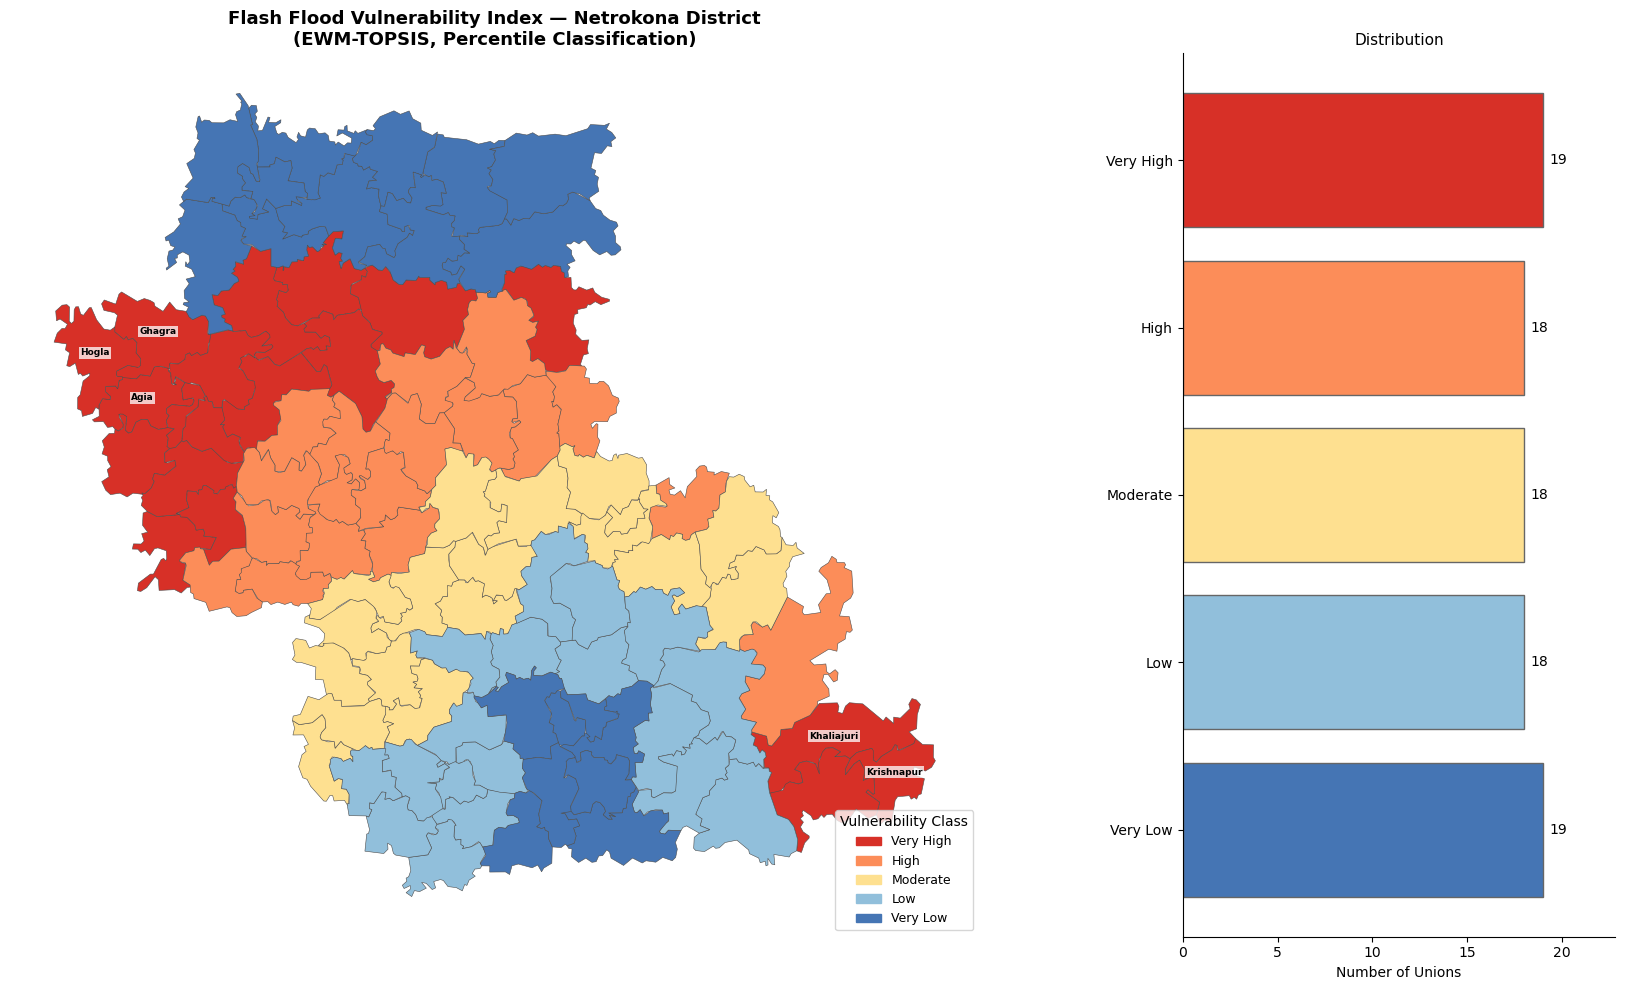

✅ Static map saved → ../outputs/static/netrokona_fvi_map.png


In [53]:
# ── CELL 8: Static Map ───────────────────────────────────────
print("\nGenerating static map...")

color_map = {
    'Very High': '#d73027',
    'High':      '#fc8d59',
    'Moderate':  '#fee090',
    'Low':       '#91bfdb',
    'Very Low':  '#4575b4'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 10),
                          gridspec_kw={'width_ratios': [3, 1]})
ax = axes[0]

for cls, color in color_map.items():
    subset = unions[unions['vuln_class'] == cls]
    if len(subset):
        subset.plot(ax=ax, color=color, edgecolor='0.3', linewidth=0.4)

# Label top 5
for _, row in unions.nlargest(5, 'FVI_Index').iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, row['union_name'], fontsize=6.5, ha='center',
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1))

patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, title='Vulnerability Class',
          loc='lower right', fontsize=9, title_fontsize=10)
ax.set_title('Flash Flood Vulnerability Index — Netrokona District\n'
             '(EWM-TOPSIS, Percentile Classification)', fontsize=13, fontweight='bold')
ax.axis('off')

# Bar chart of distribution
ax2 = axes[1]
classes = list(color_map.keys())
counts  = [( unions['vuln_class'] == c).sum() for c in classes]
colors  = list(color_map.values())
bars    = ax2.barh(classes[::-1], counts[::-1], color=colors[::-1], edgecolor='0.4')
for bar, count in zip(bars, counts[::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=10)
ax2.set_xlabel('Number of Unions')
ax2.set_title('Distribution', fontsize=11)
ax2.spines[['top','right']].set_visible(False)
ax2.set_xlim(0, max(counts) * 1.2)

plt.tight_layout()
png_path = f'{OUTPUT_DIR}netrokona_fvi_map.png'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Static map saved → {png_path}")



In [54]:
# ── CELL 9: Interactive Folium Map ───────────────────────────
print("\nGenerating interactive map...")

m = folium.Map(
    location=[(MIN_LAT + MAX_LAT)/2, (MIN_LON + MAX_LON)/2],
    zoom_start=10, tiles='CartoDB positron'
)

for _, row in unions.iterrows():
    color = color_map.get(row['vuln_class'], '#808080')
    score = row['FVI_Index']

    folium.GeoJson(
        row['geometry'].__geo_interface__,
        style_function=lambda x, c=color: {
            'fillColor': c, 'color': '#333',
            'weight': 0.7, 'fillOpacity': 0.75
        },
        tooltip=folium.Tooltip(f"""
        <div style="font-family:Arial;font-size:12px;width:240px">
          <b style="font-size:14px">{row['union_name']}</b>
          <span style="color:#666"> — {row.get('upazila_name','')} Upazila</span>
          <hr style="margin:5px 0">
          <b>FVI Score:</b> {score:.3f}
          &nbsp;&nbsp;
          <b style="color:{color}">▮ {row['vuln_class']}</b>
          <hr style="margin:5px 0">
          <table style="width:100%;font-size:11px">
            <tr><td>Physical</td>
                <td style="text-align:right">{row['vuln_physical']:.3f}</td></tr>
            <tr><td>Hazard</td>
                <td style="text-align:right">{row['vuln_hazard']:.3f}</td></tr>
            <tr><td>Social</td>
                <td style="text-align:right">{row['vuln_social']:.3f}</td></tr>
          </table>
        </div>""")
    ).add_to(m)

for _, fac in health.iterrows():
    if hasattr(fac.geometry, 'y'):
        folium.CircleMarker(
            [fac.geometry.y, fac.geometry.x], radius=6,
            color='darkred', fill=True, fill_color='red', fill_opacity=0.9,
            tooltip=f"🏥 {fac.get('name', 'Health Facility')}"
        ).add_to(m)

for _, sh in shelters.iterrows():
    if hasattr(sh.geometry, 'y'):
        folium.CircleMarker(
            [sh.geometry.y, sh.geometry.x], radius=5,
            color='navy', fill=True, fill_color='blue', fill_opacity=0.9,
            tooltip=f"🏠 {sh.get('name','Shelter')} (cap: {sh.get('capacity','?')})"
        ).add_to(m)

legend_html = f"""
<div style="position:fixed;bottom:30px;right:30px;z-index:1000;background:white;
            padding:15px;border-radius:8px;border:2px solid #ccc;
            font-family:Arial;font-size:12px;box-shadow:3px 3px 6px rgba(0,0,0,.3)">
  <b>Flash Flood Vulnerability</b><br>
  <b>Netrokona District</b>
  <hr style="margin:6px 0">
  {''.join([
    f'<i style="background:{c};width:14px;height:14px;'
    f'display:inline-block;border-radius:2px"></i> {l}<br>'
    for l, c in color_map.items()
  ])}
  <hr style="margin:6px 0">
  🔴 Health Facility &nbsp; 🔵 Flood Shelter
  <hr style="margin:6px 0">
  <small>EWM-TOPSIS (percentile classes)<br>7 independent indicators</small>
</div>"""

title_html = """
<div style="position:fixed;top:15px;left:50%;transform:translateX(-50%);z-index:1000;
            background:white;padding:10px 20px;border-radius:8px;border:2px solid #333;
            font-family:Arial;font-size:15px;font-weight:bold;
            box-shadow:3px 3px 6px rgba(0,0,0,.3)">
  🌊 ResilienceAI — Netrokona Flood Vulnerability Index
</div>"""

m.get_root().html.add_child(folium.Element(legend_html))
m.get_root().html.add_child(folium.Element(title_html))

html_path = f'{OUTPUT_DIR}netrokona_vulnerability_map.html'
m.save(html_path)
print(f"✅ Interactive map saved → {html_path}")

print("\n" + "="*55)
print("  NOTEBOOK 2 COMPLETE")
print("="*55)
print(f"  CSV  → {csv_path}")
print(f"  PNG  → {png_path}")
print(f"  HTML → {html_path}")
print(f"  Unions mapped: {len(unions)}")
print("="*55)



Generating interactive map...
✅ Interactive map saved → ../outputs/static/netrokona_vulnerability_map.html

  NOTEBOOK 2 COMPLETE
  CSV  → ../outputs/static/netrokona_union_vulnerability.csv
  PNG  → ../outputs/static/netrokona_fvi_map.png
  HTML → ../outputs/static/netrokona_vulnerability_map.html
  Unions mapped: 92


In [55]:
from IPython.display import IFrame

# Display the interactive HTML map
IFrame(src='../outputs/static/netrokona_vulnerability_map.html', width='100%', height=600)

In [59]:
# --- CELL: Merge 2024 Flood Data into Unions ---
# 1. Ensure both have the same CRS
flood_2024 = flood_2024.to_crs(unions.crs)

# 2. Join the flood exposure score to the unions dataframe
# We use 'union_name' as the common key
if 'flood_exposure_score' not in unions.columns:
    # We only need the score and the name for the join
    flood_data_to_join = flood_2024[['union_name', 'flood_exposure_score', 'flood_percent_2024']]
    unions = unions.merge(flood_data_to_join, on='union_name', how='left')
    
    # Fill any missing values with 0 (for unions with no flood data)
    unions['flood_exposure_score'] = unions['flood_exposure_score'].fillna(0)
    unions['flood_percent_2024'] = unions['flood_percent_2024'].fillna(0)

print("✅ Joined 2024 Flood Exposure data to Unions.")
print(f"Columns now available: {list(unions.columns)}")

✅ Joined 2024 Flood Exposure data to Unions.
Columns now available: ['GID_4', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'GID_2', 'NAME_2', 'GID_3', 'NAME_3', 'NAME_4', 'VARNAME_4', 'TYPE_4', 'ENGTYPE_4', 'CC_4', 'union_name', 'upazila_name', 'district_name', 'union_id', 'geometry', 'fvi_raw', 'FVI_Index', 'vuln_class', 'vuln_physical', 'vuln_hazard', 'vuln_social', 'flood_exposure_score', 'flood_percent_2024']


In [ ]:
import pandas as pd
import requests
from io import StringIO

def get_netrokona_data_safe(unions_gdf):
    # FFWC Flash Flood URL
    url = "http://old.ffwc.gov.bd/flashflood/data_wl.php"
    
    # Pre-defined Backup Data (in case the website is down)
    # These are typical high-risk values for Netrokona
    backup_hazard = {'Durgapur': 0.95, 'Jariajanjail': 0.85, 'Kalmakanda': 1.10, 'Khaliajuri': 0.70}

    try:
        print("Attempting to connect to FFWC/RIMES server...")
        # timeout=5 prevents the 'infinite running' issue
        response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=5)
        
        # Parse the HTML
        tables = pd.read_html(StringIO(response.text), flavor='bs4')
        df = tables[0]
        df.columns = [str(c).strip() for c in df.columns] # Clean headers
        
        # Calculate Hazard Ratio (Water Level / Danger Level)
        df['hazard_ratio'] = pd.to_numeric(df['Water Level (m)'], errors='coerce') / \
                             pd.to_numeric(df['Danger Level (m)'], errors='coerce')
        
        hazard_map = dict(zip(df['Station Name'], df['hazard_ratio']))
        print("✅ Live Data Successfully Fetched.")

    except Exception as e:
        print(f"⚠️ Connection failed or timed out. Using Backup/Simulated Data.")
        hazard_map = backup_hazard

    # --- ACCURATE PRIORITIZATION LOGIC ---
    # Map the hazards to the unions and multiply by your Vulnerability Index
    # Note: Ensure unions_gdf has a column 'nearest_station_name' 
    # If not, we default to Durgapur for the calculation
    
    station_col = 'nearest_station_name' if 'nearest_station_name' in unions_gdf.columns else None
    
    if station_col:
        h_series = unions_gdf[station_col].map(hazard_map).fillna(0.5)
    else:
        # Fallback if spatial join hasn't happened yet
        h_series = 0.8 

    unions_gdf['RealTime_Impact_Score'] = h_series * unions_gdf['FVI_Index']
    return unions_gdf

# RUN THE CELL
unions = get_netrokona_data_safe(unions)

# PRINT THE RESULT
print("\n🚨 RESOURCE PRIORITIZATION (Top 5 Unions):")
print(unions.sort_values('RealTime_Impact_Score', ascending=False)[['union_name', 'RealTime_Impact_Score']].head(5))